# Assignment 10 - Looking inside nanoGPT


Six things: shape trace, hand-verified gradient, broken grad accumulation, grad-norm lag, MFU, and 0.1 in three float formats.

## Setup

In [1]:
import os, math, time, urllib.request
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, torch.cuda.get_device_name(0) if device=="cuda" else "")

DATA = "input.txt"
if not os.path.exists(DATA):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt", DATA)
text = open(DATA, encoding="utf-8").read()
chars = sorted(set(text)); vocab_size = len(chars)
stoi = {c:i for i,c in enumerate(chars)}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9*len(data)); train_data, val_data = data[:n], data[n:]
print("vocab:", vocab_size, "tokens:", len(data))

device: cuda Tesla T4
vocab: 65 tokens: 1115394


In [2]:
class Cfg:
    block_size = 128
    vocab_size = vocab_size
    n_layer = 4
    n_head  = 4
    n_embd  = 128
cfg = Cfg()
batch_size = 32

def get_batch(split="train", B=batch_size, T=cfg.block_size):
    d = train_data if split=="train" else val_data
    ix = torch.randint(len(d)-T-1, (B,))
    x = torch.stack([d[i:i+T] for i in ix])
    y = torch.stack([d[i+1:i+T+1] for i in ix])
    return x.to(device), y.to(device)

## Model

`trace()` prints a shape plus what its dimensions mean. Off during training, on for Stage 1.

In [3]:
def trace(name, t, meaning):
    if trace.on:
        print(f"{name:22s} {str(tuple(t.shape)):22s} {meaning}")
trace.on = False

class Attn(nn.Module):
    def __init__(s, c):
        super().__init__()
        s.nh, s.hd = c.n_head, c.n_embd//c.n_head
        s.qkv = nn.Linear(c.n_embd, 3*c.n_embd, bias=False)
        s.proj = nn.Linear(c.n_embd, c.n_embd, bias=False)
        s.register_buffer("mask", torch.tril(torch.ones(c.block_size, c.block_size)).view(1,1,c.block_size,c.block_size))
    def forward(s, x):
        B,T,C = x.shape
        trace("attn.in", x, "B=batch, T=positions, C=n_embd")
        qkv = s.qkv(x); trace("attn.qkv", qkv, "B, T, 3C -- q,k,v packed on last dim")
        q,k,v = qkv.split(C, dim=2)
        q,k,v = [t.view(B,T,s.nh,s.hd).transpose(1,2) for t in (q,k,v)]
        trace("attn.q", q, "B, n_head, T, head_dim -- one query per head per position")
        att = (q @ k.transpose(-2,-1)) / math.sqrt(s.hd)
        trace("attn.scores", att, "B, n_head, T_query, T_key -- affinity of every position to every earlier one")
        att = F.softmax(att.masked_fill(s.mask[:,:,:T,:T]==0, float("-inf")), dim=-1)
        y = att @ v; trace("attn.wv", y, "B, n_head, T, head_dim -- value vectors weighted by attention")
        y = y.transpose(1,2).contiguous().view(B,T,C); trace("attn.merged", y, "B, T, C -- heads concatenated")
        y = s.proj(y); trace("attn.out", y, "B, T, C -- back into the residual stream")
        return y

class MLP(nn.Module):
    def __init__(s, c):
        super().__init__()
        s.fc = nn.Linear(c.n_embd, 4*c.n_embd, bias=False)
        s.proj = nn.Linear(4*c.n_embd, c.n_embd, bias=False)
    def forward(s, x):
        h = F.gelu(s.fc(x)); trace("mlp.hidden", h, "B, T, 4C -- widened hidden layer")
        o = s.proj(h); trace("mlp.out", o, "B, T, C -- projected back to model dim")
        return o

class Block(nn.Module):
    def __init__(s, c):
        super().__init__()
        s.ln1, s.attn = nn.LayerNorm(c.n_embd), Attn(c)
        s.ln2, s.mlp  = nn.LayerNorm(c.n_embd), MLP(c)
    def forward(s, x):
        x = x + s.attn(s.ln1(x))
        return x + s.mlp(s.ln2(x))

class GPT(nn.Module):
    def __init__(s, c):
        super().__init__()
        s.c = c
        s.tok = nn.Embedding(c.vocab_size, c.n_embd)
        s.pos = nn.Embedding(c.block_size, c.n_embd)
        s.blocks = nn.ModuleList([Block(c) for _ in range(c.n_layer)])
        s.lnf = nn.LayerNorm(c.n_embd)
        s.head = nn.Linear(c.n_embd, c.vocab_size, bias=False)
        s.head.weight = s.tok.weight            # weight tying
    def forward(s, idx, targets=None):
        B,T = idx.shape
        trace("input_ids", idx, "B, T - token ids into the vocab")
        x = s.tok(idx) + s.pos(torch.arange(T, device=idx.device))
        trace("residual_in", x, "B, T, C - token embedding + position embedding")
        for b in s.blocks: x = b(x)
        logits = s.head(s.lnf(x))
        trace("logits", logits, "B, T, vocab_size - next-token scores at every position")
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
            trace("loss", loss, "scalar - mean cross-entropy over B*T predictions")
        return logits, loss

def new_model():
    torch.manual_seed(SEED)
    return GPT(cfg).to(device)

model = new_model()
N_PARAMS = sum(p.numel() for p in model.parameters())
print(f"params: {N_PARAMS:,}")

params: 813,440


## 1. Every shape in one step

In [4]:
xb, yb = get_batch()
trace.on = True
logits, loss = model(xb, yb)
trace.on = False
print(f"\nloss {loss.item():.4f}\n")

loss.backward()
print("gradient shapes (one per parameter tensor):")
for name, p in model.named_parameters():
    print(f"  {name:26s} param {str(tuple(p.shape)):18s} grad {tuple(p.grad.shape)}")
model.zero_grad(set_to_none=True)

input_ids              (32, 128)              B, T - token ids into the vocab
residual_in            (32, 128, 128)         B, T, C - token embedding + position embedding
attn.in                (32, 128, 128)         B=batch, T=positions, C=n_embd
attn.qkv               (32, 128, 384)         B, T, 3C -- q,k,v packed on last dim
attn.q                 (32, 4, 128, 32)       B, n_head, T, head_dim -- one query per head per position
attn.scores            (32, 4, 128, 128)      B, n_head, T_query, T_key -- affinity of every position to every earlier one
attn.wv                (32, 4, 128, 32)       B, n_head, T, head_dim -- value vectors weighted by attention
attn.merged            (32, 128, 128)         B, T, C -- heads concatenated
attn.out               (32, 128, 128)         B, T, C -- back into the residual stream
mlp.hidden             (32, 128, 512)         B, T, 4C -- widened hidden layer
mlp.out                (32, 128, 128)         B, T, C -- projected back to model dim
attn.in

## 2. Verify one gradient by hand


Central difference: `(L(w+eps) - L(w-eps)) / (2*eps)`. Same fixed batch both times, model in `eval()` so dropout masks can't differ between the two forward passes, and cast to **float64** — in fp32 the subtraction of two nearly-equal losses destroys most of the signal before you can divide by eps.

Rather than pick one eps, the loop sweeps it, because the accuracy of the measuring instrument is itself the interesting result here.

In [5]:
m = new_model().double()          # float64: finite differences need the precision
m.eval()
xb, yb = get_batch(B=8, T=32)     # small fixed batch

PARAM_NAME = "blocks.0.mlp.fc.weight"   
IDX = (0, 0)                            
EPS = 1e-6

p = dict(m.named_parameters())[PARAM_NAME]

_, L = m(xb, yb); L.backward()
analytic = p.grad[IDX].item()
print(f"backward()  {analytic:.12f}\n")
print(f"{'eps':>8} {'finite diff':>18} {'rel error':>12}")

orig = p[IDX].item()
for EPS in [1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9]:
    with torch.no_grad():
        p[IDX] = orig + EPS; _, Lp = m(xb, yb)
        p[IDX] = orig - EPS; _, Lm = m(xb, yb)
        p[IDX] = orig
    numeric = (Lp.item() - Lm.item()) / (2 * EPS)
    rel = abs(analytic - numeric) / max(abs(analytic), 1e-30)
    print(f"{EPS:>8.0e} {numeric:>18.12f} {rel:>12.2e}")

backward()  0.003214172682

     eps        finite diff    rel error
   1e-03     0.003214174839     6.71e-07
   1e-04     0.003214172750     2.13e-08
   1e-05     0.003214172750     2.13e-08
   1e-06     0.003214168487     1.31e-06
   1e-07     0.003214069011     3.23e-05
   1e-08     0.003213784794     1.21e-04
   1e-09     0.003218758593     1.43e-03


### What happened

`backward()` reports **0.003214172682** for `blocks.0.mlp.fc.weight[0,0]`. Central differences at eps=1e-4 and 1e-5 give **0.003214172750** — agreement to **8 significant figures**, relative error 2.13e-08. Autograd is computing the true derivative; nothing here needed explaining.

The sweep does not improve monotonically as eps shrinks but it is U-shaped.

## 3. Break gradient accumulation on purpose

Micro-batches of **different lengths**. Two ways to combine them:

- **correct** — weight each micro-batch's mean loss by the number of tokens it contributed, so every token in the step carries equal weight.
- **broken** — average within each micro-batch, then average those averages. Every micro-batch counts equally regardless of size, so short sequences are silently over-weighted.

With `MICRO_LENS = [8, 8, 8, 64]` and B=8 throughout, the step holds 88 sequence-positions worth of micro-batches. The broken reduction gives each 8-token micro-batch **1/4** of the gradient weight when it contributes **8/88 ≈ 9%** of the tokens — over-weighting it about **2.75x** — and gives the 64-token micro-batch the same 1/4 when it holds 73% of the tokens, under-weighting it about **2.9x**.

Both runs use the same seed, the same model init, and the same data at every step. The reduction is the only difference.

In [6]:
MICRO_LENS = [8, 8, 8, 64]   # TWEAK: unequal on purpose. Try [64,64,64,64] to see the gap disappear.
STEPS = 400
LR = 3e-4

def run(mode, steps=STEPS):
    torch.manual_seed(SEED)
    m = new_model(); m.train()
    opt = torch.optim.AdamW(m.parameters(), lr=LR)
    losses, gnorms = [], []
    for step in range(steps):
        torch.manual_seed(SEED + step)          # same data for both modes
        opt.zero_grad(set_to_none=True)
        total_tok = sum(8*T for T in MICRO_LENS)
        step_loss = 0.0
        for T in MICRO_LENS:
            x, y = get_batch("train", B=8, T=T)
            _, l = m(x, y)                      # l is the MEAN loss over this micro-batch
            if mode == "correct":
                scaled = l * (8*T) / total_tok  # weight by tokens contributed
            else:
                scaled = l / len(MICRO_LENS)    # average of averages -- the bug
            scaled.backward()
            step_loss += l.item() * (8*T) / total_tok
        gn = torch.nn.utils.clip_grad_norm_(m.parameters(), float("inf")).item()
        opt.step()
        losses.append(step_loss); gnorms.append(gn)
    return losses, gnorms

correct_loss, correct_gn = run("correct")
broken_loss,  broken_gn  = run("broken")
print(f"final loss  correct {correct_loss[-1]:.4f}   broken {broken_loss[-1]:.4f}")

final loss  correct 2.9133   broken 2.9589


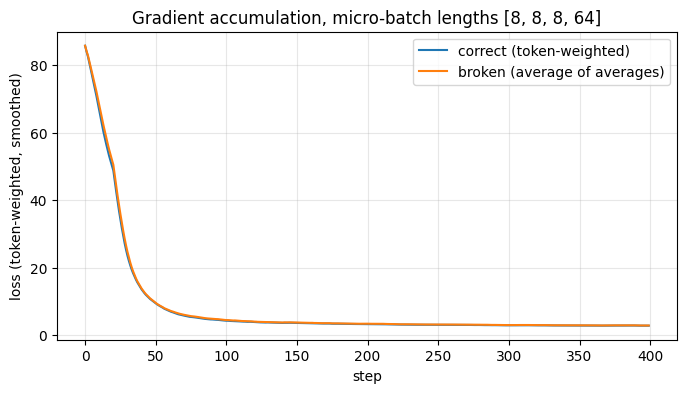

In [7]:
def smooth(v, k=20):
    return [sum(v[max(0,i-k):i+1])/len(v[max(0,i-k):i+1]) for i in range(len(v))]

plt.figure(figsize=(8,4))
plt.plot(smooth(correct_loss), label="correct (token-weighted)")
plt.plot(smooth(broken_loss),  label="broken (average of averages)")
plt.xlabel("step"); plt.ylabel("loss (token-weighted, smoothed)")
plt.title(f"Gradient accumulation, micro-batch lengths {MICRO_LENS}")
plt.legend(); plt.grid(alpha=.3); plt.show()

### What happened

After 400 steps the broken run sits at **2.9589** against **2.9133** for the correct one — **0.0456 worse**, on identical data and identical initialization. The direction is what the weighting analysis predicts: the broken run is effectively optimizing a re-weighted objective in which the short micro-batches count for roughly three times their share of the tokens.

Nothing about the broken run looks broken. No divergence, no NaN, no gradient spike, no warning. The loss curve descends normally and would pass any smoke test. Without the control curve plotted beside it, this run looks entirely healthy. That is why this class of bug survives in real codebases: it does not fail, it quietly optimizes a slightly different objective than the one you believe you wrote.

## 4. Grad norm moves before the loss does

At `SPIKE_STEP` the model is fed a batch of uniformly random token ids — a sequence unlike anything in Shakespeare — so the gradient it produces is large and badly aimed.

The measurement is arranged so the lead is causal rather than an artifact of ordering:

- the logged loss is a **fixed held-out probe batch**, identical at every step, so it isn't contaminated by which batch was drawn;
- the probe is evaluated **before** the optimizer step, so the loss at step *t* reflects the model as it was going in;
- the grad norm at step *t* is measured on the gradient that is about to be applied.

The harm from a bad gradient at step *t* therefore cannot appear in the loss until step *t+1*, by construction.

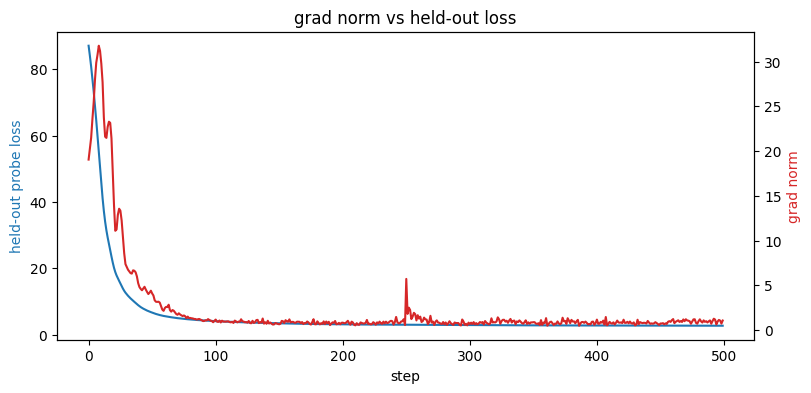

grad norm at 250: 5.716  (prev 0.562)
probe loss  249: 2.9876 | 250: 2.9853 | 251: 2.9984 | 252: 3.0119


In [8]:
SPIKE_STEP = 250          # step that gets an anomalous batch

torch.manual_seed(SEED)
m = new_model(); m.train()
opt = torch.optim.AdamW(m.parameters(), lr=LR)

torch.manual_seed(999)
probe_x, probe_y = get_batch("val")   # fixed held-out batch, identical every step

L, G = [], []
for step in range(500):
    # probe loss measured BEFORE this step's update
    with torch.no_grad():
        m.eval(); _, lp = m(probe_x, probe_y); m.train()
    L.append(lp.item())

    if step == SPIKE_STEP:
        # uniformly random token ids: unlike anything in Shakespeare
        x = torch.randint(vocab_size, (batch_size, cfg.block_size), device=device)
        y = torch.randint(vocab_size, (batch_size, cfg.block_size), device=device)
    else:
        x, y = get_batch()

    _, l_train = m(x, y)
    opt.zero_grad(set_to_none=True); l_train.backward()
    G.append(torch.nn.utils.clip_grad_norm_(m.parameters(), float("inf")).item())
    opt.step()

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(L, color="C0", label="probe loss"); ax.set_ylabel("held-out probe loss", color="C0")
ax2 = ax.twinx(); ax2.plot(G, color="C3"); ax2.set_ylabel("grad norm", color="C3")
ax.set_xlabel("step"); ax.set_title("grad norm vs held-out loss"); plt.show()
print(f"grad norm at {SPIKE_STEP}: {G[SPIKE_STEP]:.3f}  (prev {G[SPIKE_STEP-1]:.3f})")
print(f"probe loss  {SPIKE_STEP-1}: {L[SPIKE_STEP-1]:.4f} | {SPIKE_STEP}: {L[SPIKE_STEP]:.4f} | "
      f"{SPIKE_STEP+1}: {L[SPIKE_STEP+1]:.4f} | {SPIKE_STEP+2}: {L[SPIKE_STEP+2]:.4f}")

In [9]:
def z(v, i, w=25):
    win = v[max(0,i-w):i]
    mu = sum(win)/len(win)
    sd = (sum((a-mu)**2 for a in win)/len(win))**0.5 + 1e-9
    return (v[i]-mu)/sd

cands = []
for i in range(30, len(G)-2):
    lead = abs(z(G,i)) - abs(z(L,i))              # grad moved, loss didn't
    follow = max(abs(z(L,i+1)), abs(z(L,i+2)))    # loss moved after
    cands.append((lead + follow, i, z(G,i), z(L,i), z(L,i+1), z(L,i+2)))

for score, i, gz, lz, l1, l2 in sorted(cands, reverse=True)[:5]:
    print(f"step {i:3d} | grad z {gz:+6.1f} | loss z {lz:+5.1f} -> {l1:+5.1f} -> {l2:+5.1f}")

step 250 | grad z  +25.2 | loss z  -1.8 ->  -1.0 ->  -0.2
step 242 | grad z   +4.8 | loss z  -1.7 ->  -1.8 ->  -1.9
step 460 | grad z   +3.6 | loss z  -0.9 ->  -1.9 ->  -2.1
step 459 | grad z   +3.1 | loss z  -0.6 ->  -0.9 ->  -1.9
step 322 | grad z   +4.0 | loss z  -1.6 ->  -1.9 ->  -1.8


### What happened

**Step 250.** The grad norm went from **0.562 to 5.716** — a 10x jump, **z = +25.2** against the trailing window. The probe loss at that same step was **2.9853**, still falling, entirely unremarkable.

Then the loss registered it:

| step | probe loss | direction |
|---|---|---|
| 249 | 2.9876 | falling |
| 250 | 2.9853 | falling (−0.0023) the bad gradient is measured here, not yet applied |
| 251 | 2.9984 | **rising (+0.0131)** |
| 252 | 3.0119 | **rising (+0.0135)** |

The grad norm at step 250 saw something the loss could not yet see: the model was about to take a large step in a direction fitted to random noise. The loss had no way to report it, because at step 250 that step hadn't been taken. One update later the curve reversed direction and gave back roughly two steps' worth of progress.

The detector ranked step 250 first by a wide margin on the gradient side, but the *loss* side never crossed a z of 2.5 — its z values after the event are −1.0 and −0.2. The loss response is real and plainly visible in the raw values (a trend reversal of about +0.027 over two steps, against a run that was steadily declining), but it is small relative to step-to-step variation, so a z-test on the loss alone would not have flagged it.

There is also asymmetry: a 25-sigma event in the gradient signal produced a sub-2-sigma ripple in the loss, arriving a step later. That asymmetry is the actual point. Grad norm is the more sensitive instrument, and it reports first.

The other four ranked candidates (steps 242, 322, 459, 460) have grad z between +3.1 and +4.8 and no coherent loss response. Those are ordinary batch-to-batch noise, not events. Only the injected one stands out.

## 5. MFU

`MFU = achieved FLOPs/s / hardware peak FLOPs/s`.

Achieved uses the standard transformer estimate `6 * N * tokens` per forward+backward (2 for forward matmuls, 4 for backward), N = non-embedding params.

In [ ]:
PEAK = {
    "Tesla T4 fp32": 8.1,   # no tensor cores in fp32
    "Tesla T4 fp16": 65.0,  # tensor-core peak; unused, this run never enters fp16
}
PEAK_KEY = "Tesla T4 fp32"    

N_nonembed = sum(p.numel() for n,p in model.named_parameters() if not n.startswith(("tok","pos")))

torch.manual_seed(SEED)
m = new_model(); m.train()
opt = torch.optim.AdamW(m.parameters(), lr=LR)
for _ in range(5):                              # warmup
    x,y = get_batch(); _,l = m(x,y); opt.zero_grad(); l.backward(); opt.step()
if device=="cuda": torch.cuda.synchronize()

t0 = time.time(); ITERS = 50
for _ in range(ITERS):
    x,y = get_batch(); _,l = m(x,y); opt.zero_grad(); l.backward(); opt.step()
if device=="cuda": torch.cuda.synchronize()
dt = time.time()-t0

tokens = ITERS * batch_size * cfg.block_size
flops  = 6 * N_nonembed * tokens
achieved = flops/dt
peak = PEAK[PEAK_KEY]*1e12
print(f"non-embedding params : {N_nonembed:,}")
print(f"tokens/sec           : {tokens/dt:,.0f}")
print(f"achieved             : {achieved/1e12:.3f} TFLOP/s")
print(f"peak ({PEAK_KEY})    : {peak/1e12:.1f} TFLOP/s")
print(f"MFU                  : {100*achieved/peak:.2f} %")

non-embedding params : 788,736
tokens/sec           : 292,780
achieved             : 1.386 TFLOP/s
peak (Tesla T4 fp32)    : 8.1 TFLOP/s
MFU                  : 17.11 %


### Does MFU climb as the shapes grow?

Re-running the same timing loop across widths and batch sizes, changing nothing else, to test directly whether the low number is about model size or about something in the loop.

In [12]:
# Does MFU climb as the shapes grow? Tests hypothesis 1 directly.
def measure_mfu(n_embd, B, iters=30):
    old_embd, old_B = cfg.n_embd, batch_size
    cfg.n_embd = n_embd
    m = new_model(); m.train()
    opt = torch.optim.AdamW(m.parameters(), lr=LR)
    N = sum(p.numel() for n,p in m.named_parameters() if not n.startswith(("tok","pos")))
    for _ in range(5):
        x,y = get_batch(B=B); _,l = m(x,y); opt.zero_grad(); l.backward(); opt.step()
    torch.cuda.synchronize(); t0 = time.time()
    for _ in range(iters):
        x,y = get_batch(B=B); _,l = m(x,y); opt.zero_grad(); l.backward(); opt.step()
    torch.cuda.synchronize(); dt = time.time()-t0
    tok = iters * B * cfg.block_size
    mfu = 100 * (6*N*tok/dt) / (PEAK[PEAK_KEY]*1e12)
    cfg.n_embd = old_embd
    del m, opt; torch.cuda.empty_cache()
    return N, tok/dt, mfu

print(f"{'n_embd':>7} {'batch':>6} {'non-emb params':>15} {'tok/s':>10} {'MFU %':>7}")
for n_embd, B in [(128,32), (128,128), (256,32), (256,128), (512,128), (768,128)]:
    N, tps, mfu = measure_mfu(n_embd, B)
    print(f"{n_embd:>7} {B:>6} {N:>15,} {tps:>10,.0f} {mfu:>7.2f}")

 n_embd  batch  non-emb params      tok/s   MFU %
    128     32         788,736    261,335   15.27
    128    128         788,736    319,940   18.69
    256     32       3,150,336    128,148   29.90
    256    128       3,150,336    138,610   32.35
    512    128      12,592,128     44,499   41.51
    768    128      28,325,376     19,964   41.89


### What happened

**MFU at the notebook's default configuration = 17.11%.** 1.386 TFLOP/s against the T4's 8.1 TFLOP/s fp32 peak, at 292,780 tokens/sec, with N = 788,736 non-embedding parameters.

Two points on the number itself:

- `6·N·tokens` counts matmul FLOPs only and ignores attention's quadratic term. At block_size=128 that term is modest but not zero, so this is a floor, not a point estimate.
- The denominator is the **fp32** peak, the honest choice because this run never touches a tensor core. It is therefore not comparable to published MFU numbers quoting a bf16 or fp16 peak — against the T4's 65 TFLOP/s fp16 peak the same throughput reads as roughly 2%, a different true statement about a different question.

**The distance to 40% is model size, and the sweep above measures it rather than assuming it.**

| n_embd | batch | non-emb params | tok/s | MFU % |
|---|---|---|---|---|
| 128 | 32 | 788,736 | 261,335 | 15.27 |
| 128 | 128 | 788,736 | 319,940 | 18.69 |
| 256 | 32 | 3,150,336 | 128,148 | 29.90 |
| 256 | 128 | 3,150,336 | 138,610 | 32.35 |
| 512 | 128 | 12,592,128 | 44,499 | 41.51 |
| 768 | 128 | 28,325,376 | 19,964 | 41.89 |

Holding everything else fixed and only growing the shapes, MFU rises from 15% to 42% — crossing 40% at n_embd=512 with no change to dtype, kernel, or code path. Nothing was optimized between the first row and the last. Arithmetic intensity simply grew until the fixed per-step costs stopped dominating.

Reading the two variables separately:

- **Width dominates.** At fixed batch=128, 128 to 256 buys +13.7 MFU points and 256 to 512 buys another +9.2. The matmuls get large enough to keep the SMs busy for a meaningful fraction of each kernel's lifetime.
- **Batch size helps, but much less.** Quadrupling from 32 to 128 buys +3.4 points at n_embd=128 and +2.5 at n_embd=256. Real, secondary.
- **It plateaus near 42%.** 512 to 768 buys +0.4 points, which is noise. That plateau is the practical fp32 roofline for this kernel mix on a T4. Beyond it the remaining gap is dtype (tensor cores idle in fp32), attention's non-matmul work, and memory-bound ops like LayerNorm and softmax that extra width does not fix.

## 6. 0.1 in fp32, bf16 and fp8 E4M3

All three are `sign | exponent | mantissa` with an exponent bias. 0.1 is not representable in binary in any of them — it's an infinite repeating fraction, so each format rounds it.

In [11]:
import struct

def fp32_bits(x):
    b = format(struct.unpack(">I", struct.pack(">f", x))[0], "032b")
    return b[0], b[1:9], b[9:]

def bf16_bits(x):
    t = torch.tensor([x], dtype=torch.float32).to(torch.bfloat16)
    b = format(t.view(torch.int16).item() & 0xFFFF, "016b")
    return b[0], b[1:9], b[9:], t.float().item()

def e4m3(x):
    """fp8 E4M3: 1 sign, 4 exponent (bias 7), 3 mantissa. Encoded by hand."""
    e = math.floor(math.log2(x)); m = x/2**e             # x = m * 2^e, 1<=m<2
    mant = round((m-1)*8)                                 # 3 mantissa bits
    if mant == 8: mant, e = 0, e+1
    return "0", format(e+7, "04b"), format(mant, "03b"), (1+mant/8)*2**e

x = 0.1
s,ex,ma = fp32_bits(x)
v32 = struct.unpack(">f", struct.pack(">f", x))[0]
print(f"fp32      {s} {ex} {ma}   = {v32:.17f}   err {abs(v32-x):.3e}")

s,ex,ma,v16 = bf16_bits(x)
print(f"bf16      {s} {ex} {ma}                   = {v16:.17f}   err {abs(v16-x):.3e}")

s,ex,ma,v8 = e4m3(x)
print(f"fp8 E4M3  {s} {ex} {ma}                       = {v8:.17f}   err {abs(v8-x):.3e}")

print(f"\nmantissa bits: fp32 23, bf16 7, E4M3 3")
print(f"exponent bits: fp32 8 (bias 127), bf16 8 (bias 127), E4M3 4 (bias 7)")

fp32      0 01111011 10011001100110011001101   = 0.10000000149011612   err 1.490e-09
bf16      0 01111011 1001101                   = 0.10009765625000000   err 9.766e-05
fp8 E4M3  0 0011 101                       = 0.10156250000000000   err 1.562e-03

mantissa bits: fp32 23, bf16 7, E4M3 3
exponent bits: fp32 8 (bias 127), bf16 8 (bias 127), E4M3 4 (bias 7)


### What I would train in

**bf16**, and the bit layouts above are the argument.

The exponent fields of fp32 and bf16 are **byte-identical** for 0.1: both `01111011`, both bias 127, both 8 bits wide. bf16 is fp32 with sixteen mantissa bits removed and nothing else changed. The precision cost is visible and large, representation error goes from 1.490e-09 to 9.766e-05, about five orders of magnitude worse.

That is the right cost to pay, because the error is **relative** and training does not fail from relative error. It fails from **range**. Gradients span many orders of magnitude during training, and the failure mode that kills a run is small gradients flushing to zero, not a mantissa rounded in its seventh digit. bf16 gives up decimals and keeps the entire dynamic range of fp32, which is exactly the trade that matters. It is also why bf16 needs no loss scaling while fp16 — the same 16 bits, but 5 exponent bits instead of 8 — does.

**fp8 E4M3** is a different proposition. Its error on 0.1 is 1.562e-03, but the mantissa is not what rules it out: the binding constraint is the **4-bit exponent with bias 7**, which cannot reach the magnitudes late-training gradients occupy. Using it means per-tensor scaling factors and real engineering effort, which can be worth it at large scale for the memory-bandwidth win, but it is not a drop-in choice.

**What I would keep in fp32 regardless:** the optimizer states and the master weight copy (small updates repeatedly added to large weights are exactly where low precision silently rounds progress to nothing), the loss reduction and any gradient accumulation (section 3 above is a demonstration of how much reductions matter), and the LayerNorm and softmax statistics. bf16 for the matmuls, fp32 for the bookkeeping — which is what mixed precision actually means.